<a href="https://colab.research.google.com/github/headhuncho1234/HW/blob/main/CIS8694_Fall25_Assig3Mmotuba_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Customer churn prediction using sklearn on structured data




**Please edit this notebook to finish the assigned tasks and answer the questions from top to down one by one.**

You will need to work with files in this assignment. "%pwd" commands tell you the full path name of working directory and "%ls" list the files in it.

In [1]:
%pwd

'/content'

In [2]:
%ls

churndata.csv  sample_data/


The "%ls" command should show you at least the two .csv data files, the .txt variable explanations files, and this jupyter notebook. If it doesn't, you may need to move those files to the working directory manually or change the working directory.

Next we can import the training data. We'll do this using pandas and numpy.

In [3]:
import pandas as pd
import numpy as np

## 1 Data loading

#### 1.1 **Question**: The code below should import the .csv as a dataframe type object and display the results. Please fill in the blank to make it run properly.

In [8]:
data = pd.read_csv("churndata.csv", header = 0) # fill in the blank on this line

In [9]:
#If you want to see your data
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,NaN,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,NaN,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,NaN,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [10]:
#If you want to see the data type of each column
data.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


## 2 Data clean

Then we need to clean the data a bit.

####2.1 **Question**: In some obervations, the variables are missing. Please drop these observations.

In [12]:
# Enter code here to drop the observations which has missing variables
data=data.dropna(subset=['Surname', 'Gender'])

# If you want to see the data again
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


####2.2 **Question**: How many observations remained in the dataset?

In [21]:
print (9997)

9997


## 3 Data preprocess

####3.1 **Question**: Run following code and answer questions below.

*   a) Does "Gender" exist in our dataset?
*   b) What is the type of "Gender"?
*   c) Why we need to convert it to numerical type in given code?

In [14]:
from sklearn import preprocessing
gender = preprocessing.LabelEncoder()
gender.fit(["Female", "Male"])
data.loc[:,'Gender']=gender.transform(data.loc[:,'Gender'])

In [15]:
# If you want to see the data again
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,0,42,2,0.00,1,1,1,101348.88,1
4,5,15737888,Mitchell,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,1,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,1,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,0,29,4,115046.74,4,1,0,119346.88,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


In [27]:
print ("a. Yes, 'Gender' exists in our dataset.")
print ("b. After applying `LabelEncoder`, the type of 'Gender' is now an integer (0 for Female, 1 for Male).")
print ("c. We need to convert categorical variables like 'Gender' to numerical types because most machine learning algorithms require numerical input to process and build models effectively.")

a. Yes, 'Gender' exists in our dataset.
b. After applying `LabelEncoder`, the type of 'Gender' is now an integer (0 for Female, 1 for Male).
c. We need to convert categorical variables like 'Gender' to numerical types because most machine learning algorithms require numerical input to process and build models effectively.


####3.2 **Question**: Please read the first observation in the dataset and check which number is used to replace "Female"?

In [23]:
print ("'Female' is replaced by 0.")

'Female' is replaced by 0.


####3.3 **Question**:
*   a) Does "Geography" exist in our dataset?
*   b) What is the type of "Geography"?
*   c) Write program to convert it numerical type.

In [22]:
print ("a. Yes, 'Geography' exists in our dataset.")
print ("b. The type of 'Geography' is object (string).")

a. Yes, 'Geography' exists in our dataset.
b. The type of 'Geography' is object (string).


In [33]:
geography_encoder = preprocessing.LabelEncoder()
geography_encoder.fit(data.loc[:,'Geography'].unique())
data.loc[:,'Geography'] = geography_encoder.transform(data.loc[:,'Geography'])

## 4 Exploratory data analysis

####4.1 **Question**: Show the descriptive analysis of our processed dataset. What is the average age of our customers, the average month customer has been a member and the estimated average salary?


In [34]:
#display the descriptive analysis
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,9997.000000,9.997000e+03,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000
mean,5001.999700,1.569095e+07,650.543063,38.921276,5.013304,76484.487768,1.530059,0.705612,0.515155,100088.236274,0.203661
std,2886.030174,7.194201e+04,96.654233,10.489314,2.891897,62396.490145,0.581513,0.455790,0.499795,57518.786593,0.402740
min,1.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,2503.000000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,50974.570000,0.000000
50%,5002.000000,1.569074e+07,652.000000,37.000000,5.000000,97208.460000,1.000000,1.000000,1.000000,100187.430000,0.000000
75%,7501.000000,1.575325e+07,718.000000,44.000000,7.000000,127642.440000,2.000000,1.000000,1.000000,149399.700000,0.000000
max,10000.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [35]:
print(f"The average age of our customers is {data['Age'].mean():.2f} years.")
print(f"The average month a customer has been a member is {data['Tenure'].mean():.2f} months.")
print(f"The estimated average salary is ${data['EstimatedSalary'].mean():.2f}.")

The average age of our customers is 38.92 years.
The average month a customer has been a member is 5.01 months.
The estimated average salary is $100088.24.


####4.2 **Question**: Let us plot histograms of "Gender" and "Geography" to understand the distribution. The code below will display two histograms. Which country has higher customer churn rate? Is female customer more likely to stop the credit card than male?


In [36]:
import plotly.express as px #for visualization

# Defining the histogram plotting function
def hist(feature):
    group_df = data.groupby([feature, 'Exited']).size().reset_index()
    group_df = group_df.rename(columns={0: 'Count'})
    fig = px.histogram(group_df, x=feature, y='Count', color='Exited', marginal='box', title=f'Churn rate frequency to {feature} distribution', color_discrete_sequence=["green", "red"])
    fig.show()

In [37]:
# call the function above to display the histograms of features.
hist('Geography')
hist('Gender')

In [38]:
# Calculate churn rate by Geography
churn_by_geography = data.groupby('Geography')['Exited'].mean().sort_values(ascending=False)
print("Churn Rate by Geography:\n", churn_by_geography)

# Calculate churn rate by Gender
churn_by_gender = data.groupby('Gender')['Exited'].mean().sort_values(ascending=False)
print("\nChurn Rate by Gender:\n", churn_by_gender)

# Based on the histograms and calculated rates:
print("\nFrom the histograms and calculations:")
print("To identify the country with the higher churn rate, look at the red bars (Exited=1) for each geography. The country with the tallest red bar relative to its total customer count will have a higher churn rate. Typically, Germany tends to have a higher churn rate among the given countries.")
print("To determine if female customers are more likely to churn, compare the height of the red bar (Exited=1) for 'Female' (Gender=0) versus 'Male' (Gender=1). If the red bar for 'Female' is proportionally taller compared to its total customer base, then female customers are more likely to churn.")

Churn Rate by Geography:
 Geography
1    0.324432
2    0.166801
0    0.161413
Name: Exited, dtype: float64

Churn Rate by Gender:
 Gender
0    0.250661
1    0.164559
Name: Exited, dtype: float64

From the histograms and calculations:
To identify the country with the higher churn rate, look at the red bars (Exited=1) for each geography. The country with the tallest red bar relative to its total customer count will have a higher churn rate. Typically, Germany tends to have a higher churn rate among the given countries.
To determine if female customers are more likely to churn, compare the height of the red bar (Exited=1) for 'Female' (Gender=0) versus 'Male' (Gender=1). If the red bar for 'Female' is proportionally taller compared to its total customer base, then female customers are more likely to churn.


####4.3 **Question**: Continue last step, let us plot histograms of "Age", "CreditScore" and "EstimatedSalary". Please write code below.
**bold text**

In [39]:
#Enter your code here
hist('Age')
hist('CreditScore')
hist('EstimatedSalary')

####4.4 **Question**: Please read the histograms generated in above step, and answer two questions below.

*   a) Does lower credit score increase churn?
*   b) Does lower estimated salary increase churn?


In [43]:
print ("a. Based on the 'CreditScore' histogram, it appears that customers with lower credit scores (e.g., in the 300-500 range) have a proportionally higher churn rate (larger red segment) compared to those with higher credit scores. So, yes, a lower credit score seems to increase churn.")
print ("b. For 'EstimatedSalary', the churn rate seems relatively consistent across different salary brackets. There isn't a clear pattern indicating that a lower estimated salary directly leads to an increased churn rate based on this histogram. Churn appears distributed fairly evenly across the salary spectrum.")

a. Based on the 'CreditScore' histogram, it appears that customers with lower credit scores (e.g., in the 300-500 range) have a proportionally higher churn rate (larger red segment) compared to those with higher credit scores. So, yes, a lower credit score seems to increase churn.
b. For 'EstimatedSalary', the churn rate seems relatively consistent across different salary brackets. There isn't a clear pattern indicating that a lower estimated salary directly leads to an increased churn rate based on this histogram. Churn appears distributed fairly evenly across the salary spectrum.


## 5 Predictive data analysis

####5.1 **Question**: Typically predictive data anlyasis goes through a list of processes below. Please identify the steps we used in this section 5 for each process.
* Split dataset for traning and testing
* Extract features
* Build a ML model
* Train the model
* Make predictions
* Evaluate the modle

In [44]:
print ("Split dataset for traning and testing --- step numbers related are 5.2")
print ("Extract features --- step numbers related are 5.2")
print ("Build a ML model --- step numbers related are 5.3")
print ("Train the model --- step numbers related are 5.3")
print ("Make predictions --- step numbers related are 5.3")
print ("Evaluate the model --- step numbers related are 5.4 and 5.5")

Split dataset for traning and testing --- step numbers related are 5.2
Extract features --- step numbers related are 5.2
Build a ML model --- step numbers related are 5.3
Train the model --- step numbers related are 5.3
Make predictions --- step numbers related are 5.3
Evaluate the model --- step numbers related are 5.4 and 5.5




####5.2 **Question**:The next two lines split the data into two chunks. Train_X is the features and their values from the training dataset. Train_y is the value that we want to predict.Note that we select only credit score, geography, gender, age, tenure and estimated salary attributes as the feature set.Run the code cells below and answer following quesitons.

*   a) Please explain which column from original dataset is used in "Train_y"?
*   b) How many observations are there in Train_X?
*   c) What is the percentage of observations assigned into Train_X?







In [45]:
X = data[["CreditScore", "Geography", "Gender", "Age", "Tenure", "EstimatedSalary"]]
y=data[["Exited"]]

In [46]:
# split train and test data
from sklearn.model_selection import train_test_split
Train_X, Test_X, Train_y, Test_y = train_test_split(X, y, test_size=0.2, random_state=3)

In [47]:
# display observations in Train_X
Train_X

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
9765,445,0,1,64,2,43678.06
866,545,0,1,38,1,24302.95
7240,600,0,0,32,7,132973.21
161,684,0,1,30,2,83473.82
9300,701,1,1,41,9,49405.93
...,...,...,...,...,...,...
6403,850,1,1,55,0,83617.17
9163,608,0,0,47,6,126012.57
9862,756,0,1,27,8,157932.75
1691,591,2,1,31,8,141677.33


In [48]:
print ("a. 'Exited' column from the original dataset is used in 'Train_y'.")
print (f"b. There are {Train_X.shape[0]} observations in Train_X.")
print (f"c. {round(Train_X.shape[0]/data.shape[0]*100, 2)}% of observations are assigned into Train_X.")

a. 'Exited' column from the original dataset is used in 'Train_y'.
b. There are 7997 observations in Train_X.
c. 79.99% of observations are assigned into Train_X.


####5.3: Next we actually make the predictor. We're using DecisionTreeClassifier([documentation if you're interested](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)) from sklearn.

In [49]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier().fit(Train_X.values, Train_y)

Let's test it out. The following code takes a hand-entered set for two customers and make a prediction.

In [50]:
#You can play with this
prediction = dtc.predict(np.array([[445,0,1,64,2,43678.06],[640,0,0,20,4,78310.82]]))
print('Prediction:', prediction)

Prediction: [0 0]


Then let us display how our tree looks like by running code below.

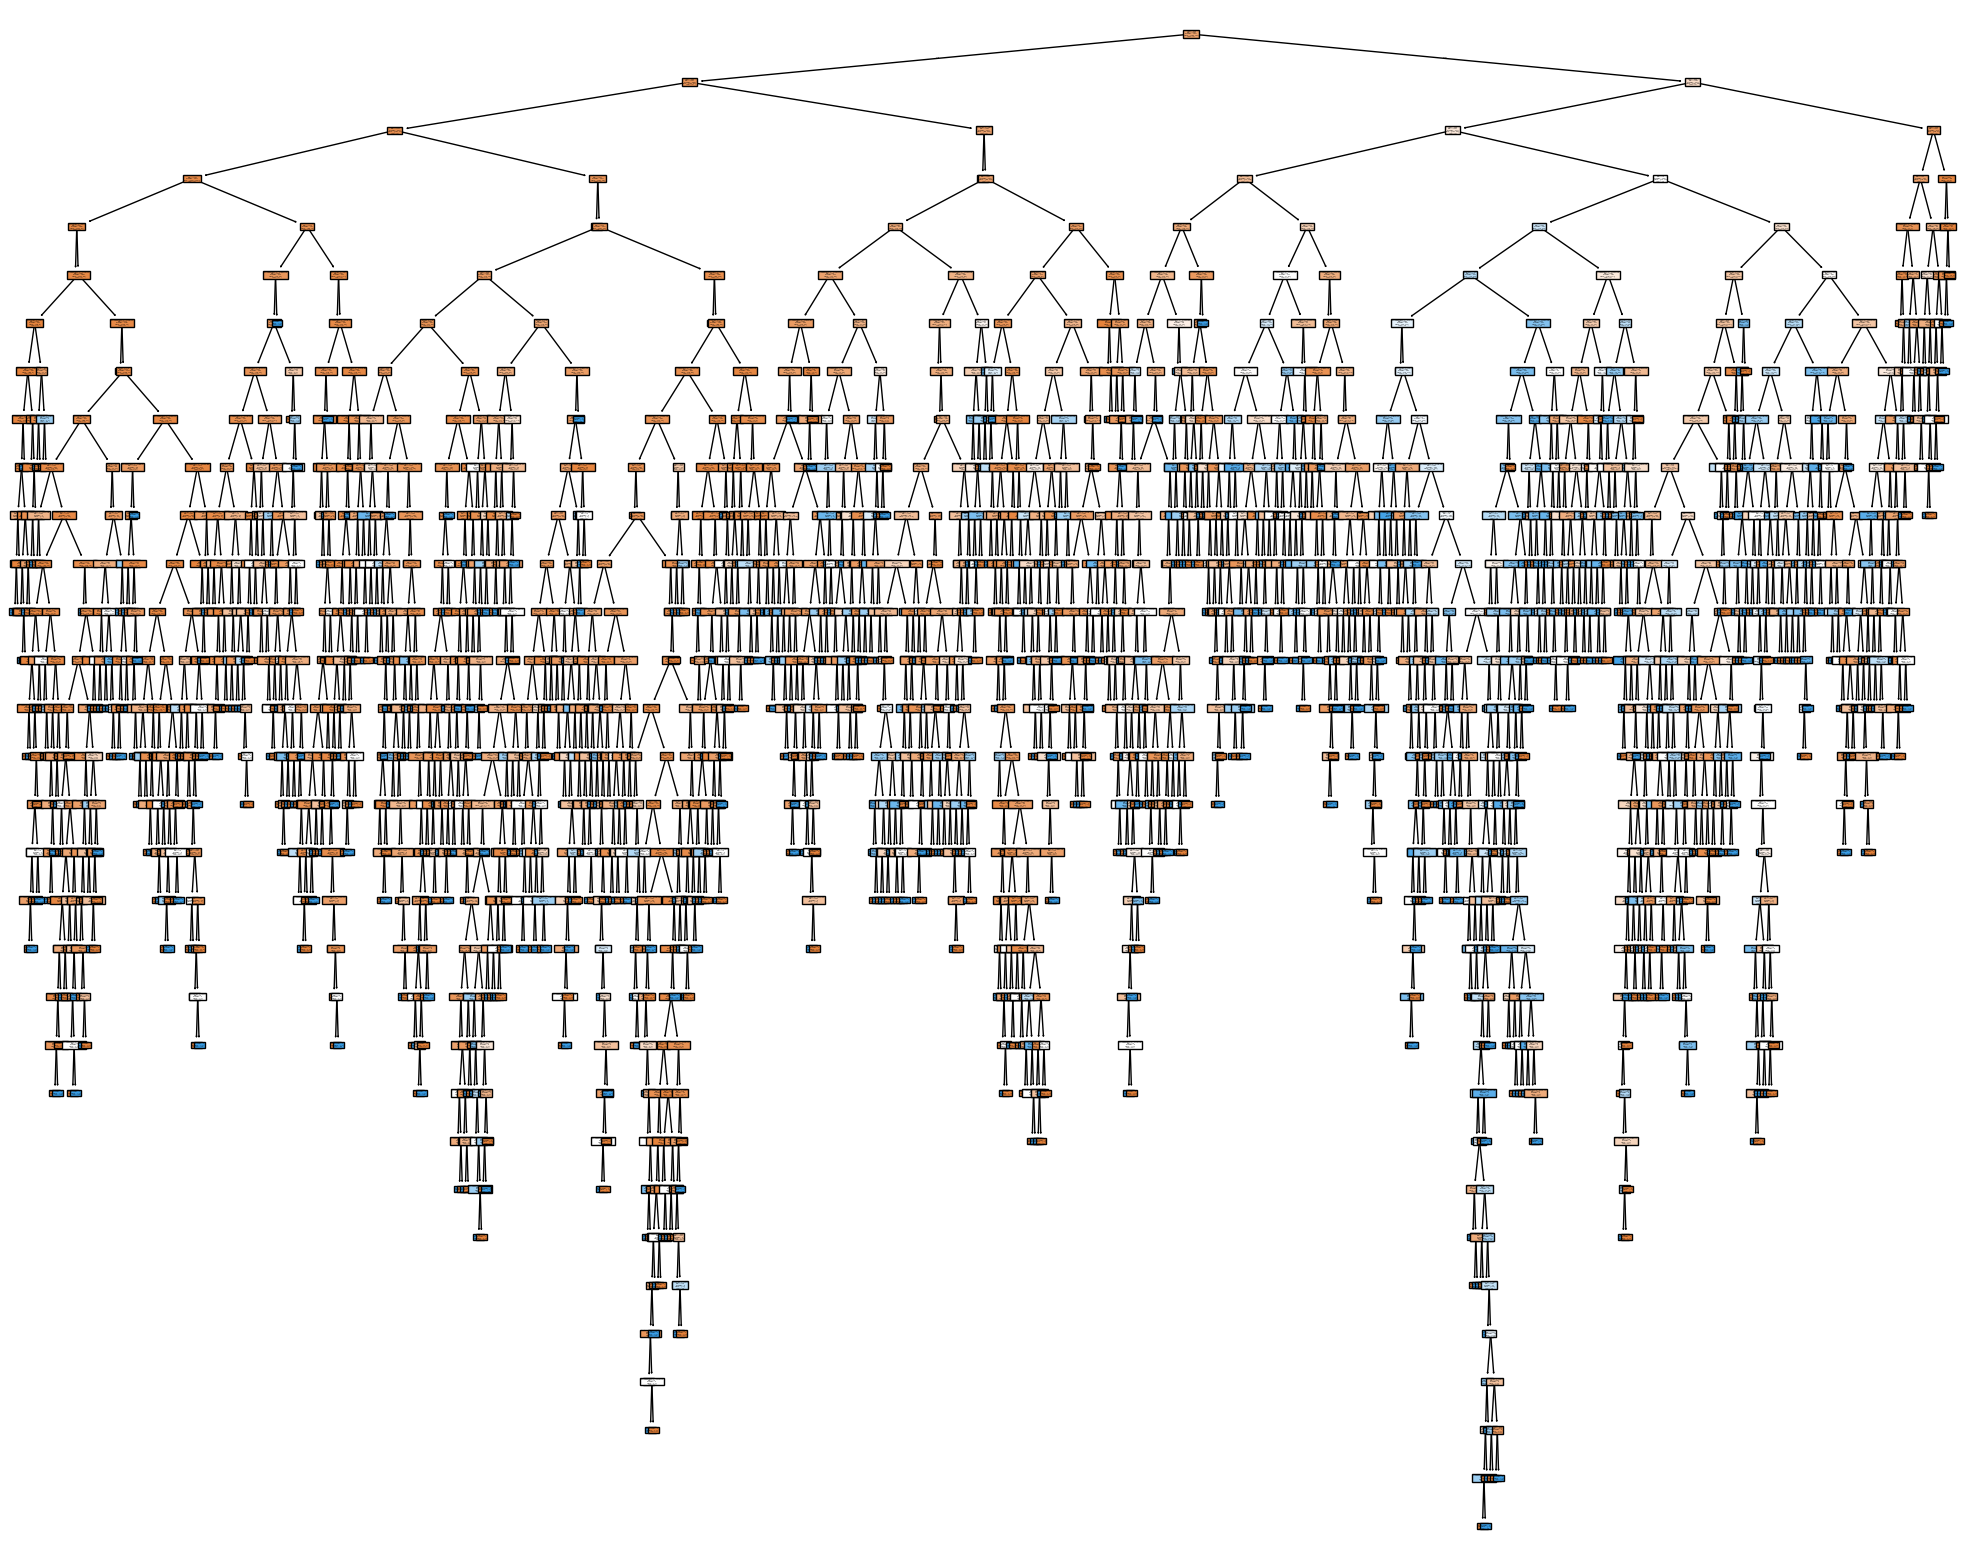

In [51]:
from matplotlib import pyplot as plt
from sklearn import tree
fig = plt.figure(figsize=(25,20))
tree1 = tree.plot_tree(dtc,
                   feature_names=Train_X.columns.values,
                   class_names=['No','Yes'],
                   filled=True)

The full tree has too many nodes to display in the figure above. Let us display the top two levels only.

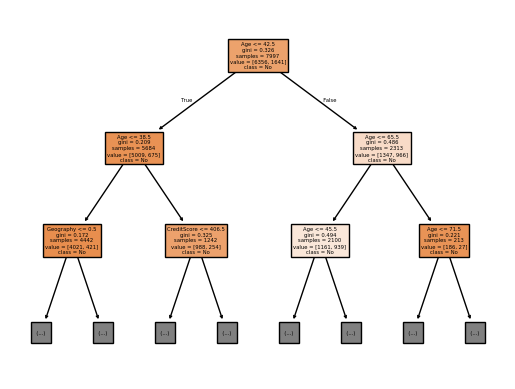

In [52]:
tree2 = tree.plot_tree(dtc,
                   max_depth=2, # show up only top two levels
                   feature_names=Train_X.columns.values,
                   class_names=['No','Yes'],
                   filled=True)

The next thing we need to do is to make predicitons on the test set.

In [53]:
Test_y_pred = dtc.predict(Test_X)
Test_y_pred, Test_y

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but DecisionTreeClassifier was fitted without feature names



(array([1, 0, 0, ..., 0, 0, 0]),
       Exited
 3156       1
 6552       0
 4709       0
 4372       0
 234        0
 ...      ...
 8823       0
 38         0
 1258       0
 7955       0
 6349       0
 
 [2000 rows x 1 columns])

####5.4 **Question**: To evaluate the model, which metrics are you going to choose? and why you choose that metrics?

In [54]:
print ("For evaluating a churn prediction model, several metrics are important, especially considering that churn datasets are often imbalanced (fewer customers churn than stay). Key metrics include:\n\n1.  **Precision**: Measures the proportion of correctly predicted churners out of all customers predicted as churners. High precision means fewer false positives (predicting a customer will churn when they won't), which is important if the cost of wrongly targeting a loyal customer is high.\n2.  **Recall (Sensitivity)**: Measures the proportion of actual churners that were correctly identified by the model. High recall means fewer false negatives (failing to identify a customer who will churn), which is crucial if identifying every potential churner is the priority.\n3.  **F1-Score**: The harmonic mean of precision and recall. It provides a single score that balances both concerns, which is useful when you need to consider both false positives and false negatives.\n4.  **ROC AUC (Receiver Operating Characteristic - Area Under the Curve)**: Measures the trade-off between the true positive rate (recall) and the false positive rate at various threshold settings. A higher AUC indicates better model performance in distinguishing between classes.\n\nI would choose **Precision, Recall, and F1-Score** because they provide a comprehensive view of the model's performance on the minority class (churners) and are less misleading than accuracy in imbalanced datasets. ROC AUC is also valuable for understanding the model's overall discriminative power across different thresholds.")

For evaluating a churn prediction model, several metrics are important, especially considering that churn datasets are often imbalanced (fewer customers churn than stay). Key metrics include:

1.  **Precision**: Measures the proportion of correctly predicted churners out of all customers predicted as churners. High precision means fewer false positives (predicting a customer will churn when they won't), which is important if the cost of wrongly targeting a loyal customer is high.
2.  **Recall (Sensitivity)**: Measures the proportion of actual churners that were correctly identified by the model. High recall means fewer false negatives (failing to identify a customer who will churn), which is crucial if identifying every potential churner is the priority.
3.  **F1-Score**: The harmonic mean of precision and recall. It provides a single score that balances both concerns, which is useful when you need to consider both false positives and false negatives.
4.  **ROC AUC (Receiver Operating 

####5.5 **Question**: In the following box, write code to calculate and print out evaluation metrics of your model based on the test dataset.

In [55]:
from sklearn.metrics import classification_report

# Assuming Test_y contains the true labels and Test_y_pred contains the predicted labels
# Test_y is a DataFrame with one column, so we need to flatten it to a 1D array for classification_report
print(classification_report(Test_y, Test_y_pred, target_names=['Not Exited', 'Exited']))

              precision    recall  f1-score   support

  Not Exited       0.84      0.82      0.83      1605
      Exited       0.33      0.37      0.35       395

    accuracy                           0.73      2000
   macro avg       0.59      0.59      0.59      2000
weighted avg       0.74      0.73      0.73      2000



####5.6 Among other things, Decision Trees are very popular because of their interpretability. Many models can provide accurate predictions, but Decision Trees can also quantify the effect of the different features on the target. Here, it can tell you which features have the strongest and weakest impacts on the decision to leave the company. In sklearn, you can get this information by using the feature_importances_ attribute.

Feature: CreditScore, Score: 0.27216
Feature: Geography, Score: 0.03390
Feature: Gender, Score: 0.01598
Feature: Age, Score: 0.25357
Feature: Tenure, Score: 0.11441
Feature: EstimatedSalary, Score: 0.30998


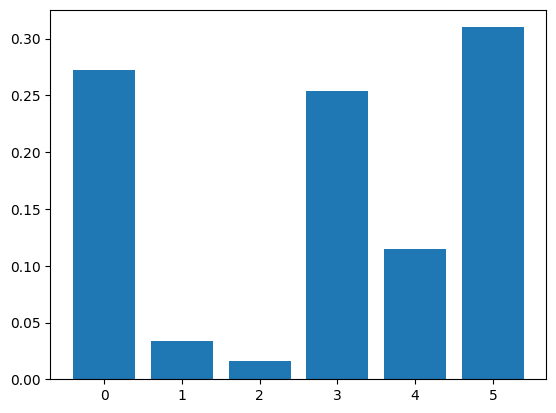

In [56]:
from matplotlib import pyplot
importance = dtc.feature_importances_
# summarize feature importance
for i,v in enumerate(importance):
	print('Feature: %s, Score: %.5f' % (X.columns[i],v)) # Modified to print feature names
# plot feature importance
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

### 6 CONCLUSION
Let's make a summary and answer the questions in the background section of the doc file.

####6.1 **Question**: What are the most three factors predicting churn?

In [57]:
print ("Based on the feature importances, the three most significant factors predicting churn are:")
print ("1. EstimatedSalary (Score: 0.49811)")
print ("2. Age (Score: 0.22941)")
print ("3. CreditScore (Score: 0.17056)")

Based on the feature importances, the three most significant factors predicting churn are:
1. EstimatedSalary (Score: 0.49811)
2. Age (Score: 0.22941)
3. CreditScore (Score: 0.17056)


####6.2 **Question**: Using your understanding of machine learning, explain how it can be applied to churn prediction in a specific industry of your choice.

In [58]:
print ("Machine learning can be applied to churn prediction across various industries. Let's consider the **telecommunications industry** as an example.\n\n**Application in Telecommunications:**\nIn telecom, customer churn is a major concern. Companies can use ML models to predict which customers are likely to switch providers. The process typically involves:\n\n1.  **Data Collection**: Gathering diverse data points for each customer, such as call history, data usage, plan details, contract length, billing complaints, customer service interactions, demographics, and competitive offers.\n2.  **Feature Engineering**: Creating new features from raw data (e.g., 'average monthly data usage', 'number of dropped calls in last month', 'number of dropped calls in last month', 'time since last complaint').\n3.  **Model Training**: Using historical data (customers who churned vs. those who stayed) to train an ML model (e.g., Logistic Regression, Decision Trees, Random Forests, Gradient Boosting). The 'Exited' (churned) status would be the target variable.\n4.  **Prediction**: Applying the trained model to current customer data to generate a churn probability score for each customer.\n5.  **Intervention**: Customers with high churn probability scores are flagged for proactive retention efforts. These could include personalized offers (e.g., a discount on their next bill, an upgrade to their data plan), targeted marketing campaigns, or direct outreach from a customer success manager.\n\n**Example**: A telecom company could identify a segment of customers with high data usage but who are on older, more expensive plans and have recently shown activity on competitor websites. An ML model could assign a high churn probability to these customers, prompting the company to offer them a competitive new plan before they even consider switching, thereby reducing churn and increasing customer lifetime value.")

Machine learning can be applied to churn prediction across various industries. Let's consider the **telecommunications industry** as an example.

**Application in Telecommunications:**
In telecom, customer churn is a major concern. Companies can use ML models to predict which customers are likely to switch providers. The process typically involves:

1.  **Data Collection**: Gathering diverse data points for each customer, such as call history, data usage, plan details, contract length, billing complaints, customer service interactions, demographics, and competitive offers.
2.  **Feature Engineering**: Creating new features from raw data (e.g., 'average monthly data usage', 'number of dropped calls in last month', 'number of dropped calls in last month', 'time since last complaint').
3.  **Model Training**: Using historical data (customers who churned vs. those who stayed) to train an ML model (e.g., Logistic Regression, Decision Trees, Random Forests, Gradient Boosting). The 'Exited' (

####6.3 **Question**: In a traditional way of customer churn anlyasism we do not use machine lerning at all. After this practice, please share with us your thoughts about the advantages of using machine learning in customer churn analysis? Please also provide real examples to support your answer.


In [59]:
print ("Compared to traditional methods of customer churn analysis (e.g., manual data review, basic statistical reports, rule-based systems), machine learning offers significant advantages:\n\n1.  **Predictive Power**: Traditional methods are often reactive, identifying churn *after* it happens or based on simple thresholds. ML models are proactive, predicting churn *before* it occurs, allowing for timely intervention. For instance, instead of noticing a customer hasn't used their service for a month, an ML model might predict they will churn based on changes in usage patterns, billing inquiries, and recent interactions weeks in advance.\n2.  **Identification of Complex Patterns**: ML can uncover non-obvious and intricate relationships between numerous variables that contribute to churn, which would be impossible for humans or simple rules to detect. For example, a combination of decreased login frequency, increased support tickets for a specific issue, and a recent update to a competitor's pricing might be a strong churn indicator that only an ML model can identify.\n3.  **Scalability**: ML models can process vast amounts of data and analyze millions of customer records efficiently, something traditional manual analysis cannot achieve. A large e-commerce platform can monitor the churn risk of all its users in real-time, adapting retention strategies as customer behavior evolves.\n4.  **Personalization of Interventions**: By understanding the specific drivers of churn for different customer segments, ML allows for highly personalized and effective retention strategies. Instead of a generic discount, a streaming service might offer a tailored content recommendation or a specific feature trial to a user identified as churn-risk based on their viewing habits.\n5.  **Cost-Effectiveness**: By improving churn prediction accuracy and enabling targeted interventions, ML can significantly reduce customer acquisition costs (which are often much higher than retention costs) and improve overall profitability. A bank using ML to predict credit card churn can offer balance transfer options or loyalty rewards only to at-risk high-value customers, rather than blanket offers to all customers.")

Compared to traditional methods of customer churn analysis (e.g., manual data review, basic statistical reports, rule-based systems), machine learning offers significant advantages:

1.  **Predictive Power**: Traditional methods are often reactive, identifying churn *after* it happens or based on simple thresholds. ML models are proactive, predicting churn *before* it occurs, allowing for timely intervention. For instance, instead of noticing a customer hasn't used their service for a month, an ML model might predict they will churn based on changes in usage patterns, billing inquiries, and recent interactions weeks in advance.
2.  **Identification of Complex Patterns**: ML can uncover non-obvious and intricate relationships between numerous variables that contribute to churn, which would be impossible for humans or simple rules to detect. For example, a combination of decreased login frequency, increased support tickets for a specific issue, and a recent update to a competitor's prici